In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
train_path = "/content/drive/MyDrive/leaves/train"
test_path  = "/content/drive/MyDrive/leaves/test"

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:

DATASET_PATH = "/content/drive/MyDrive/leaves"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [13]:
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
NUM_CLASSES = train_data.num_classes
print("Number of classes:", NUM_CLASSES)
print("Classes:", train_data.class_indices)

Found 4274 images belonging to 12 classes.
Found 110 images belonging to 12 classes.
Number of classes: 12
Classes: {'Alstonia Scholaris': 0, 'Arjun': 1, 'Bael': 2, 'Basil': 3, 'Chinar': 4, 'Gauva': 5, 'Jamun': 6, 'Jatropha': 7, 'Lemon': 8, 'Mango': 9, 'Pomegranate': 10, 'Pongamia Pinnata': 11}


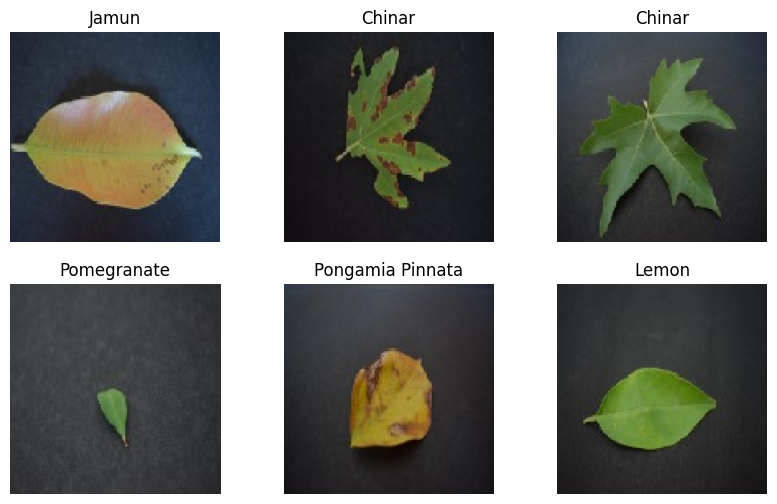

In [14]:
images, labels = next(train_data)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [15]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,868 (28.21 MB)

 Trainable params: 7,393,868 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 983s 7s/step - accuracy: 0.3708 - loss: 1.8245 - val_accuracy: 0.5455 - val_loss: 1.3251
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 128s 954ms/step - accuracy: 0.6467 - loss: 1.0456 - val_accuracy: 0.7273 - val_loss: 1.0241
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 127s 944ms/step - accuracy: 0.7511 - loss: 0.7663 - val_accuracy: 0.7818 - val_loss: 1.0123
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 112s 834ms/step - accuracy: 0.7960 - loss: 0.6046 - val_accuracy: 0.8545 - val_loss: 0.8639
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 121s 897ms/step - accuracy: 0.8320 - loss: 0.5222 - val_accuracy: 0.8273 - val_loss: 0.8919
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 131s 974ms/step - accuracy: 0.8575 - loss: 0.4166 - val_accuracy: 0.8273 - val_loss: 1.0186
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 146s 998ms/step - accuracy: 0.8718 - loss: 0.3851 - val_accuracy: 0.8636 - val_loss: 1.0670
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 129s 964ms/step - accuracy: 0.9020 - lo

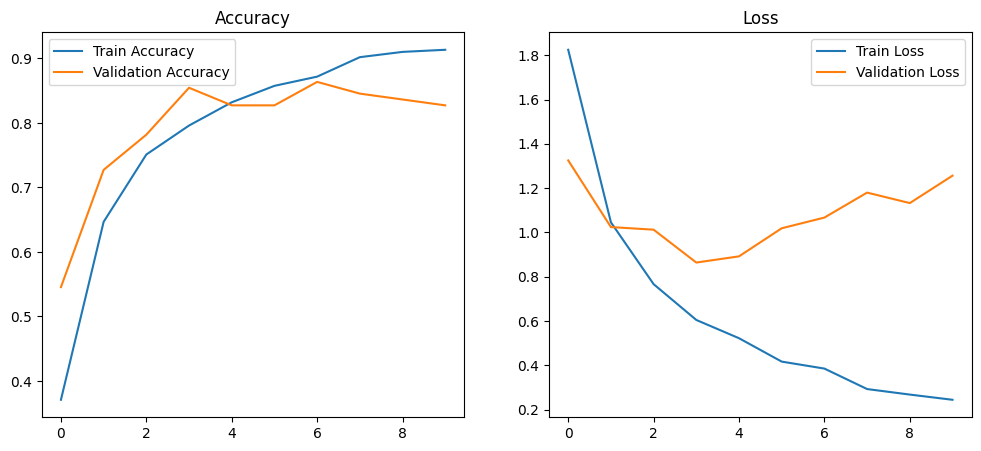

In [17]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [18]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.8273 - loss: 1.2561
Test Accuracy: 0.8272727131843567


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step


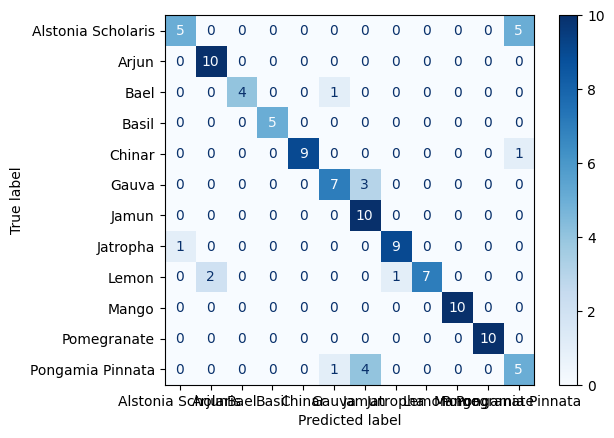

In [19]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=test_data.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [21]:
MODEL_PATH = "/content/drive/MyDrive/leaves/binary_cnn_model.keras"
model.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!
